In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
print(os.getcwd())

df = pd.read_csv('all_stocks_5yr.csv')  # replace with the actual filename
print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())



C:\Users\Travis Cheong
(619040, 7)
         date   open   high    low  close    volume Name
0  2013-02-08  15.07  15.12  14.63  14.75   8407500  AAL
1  2013-02-11  14.89  15.01  14.26  14.46   8882000  AAL
2  2013-02-12  14.45  14.51  14.10  14.27   8126000  AAL
3  2013-02-13  14.30  14.94  14.25  14.66  10259500  AAL
4  2013-02-14  14.94  14.96  13.16  13.99  31879900  AAL
date       object
open      float64
high      float64
low       float64
close     float64
volume      int64
Name       object
dtype: object
date       0
open      11
high       8
low        8
close      0
volume     0
Name       0
dtype: int64


In [14]:
print("Number of stocks:", df['Name'].nunique())


Number of stocks: 505


In [15]:
df['date'] = pd.to_datetime(df['date'])
print("Date range:", df['date'].min(), "to", df['date'].max())



Date range: 2013-02-08 00:00:00 to 2018-02-07 00:00:00


In [16]:
nvda = df[df['Name'] == 'NVDA'].copy()
print("\nNVDA rows:", len(nvda))
print(nvda.head())



NVDA rows: 1259
             date    open     high    low  close    volume  Name
422633 2013-02-08  12.370  12.4699  12.29  12.37   7677336  NVDA
422634 2013-02-11  12.470  12.6350  12.35  12.51  10207599  NVDA
422635 2013-02-12  12.395  12.5650  12.38  12.43   6945065  NVDA
422636 2013-02-13  12.440  12.6650  12.33  12.37  21322573  NVDA
422637 2013-02-14  12.200  12.7400  12.05  12.73  22049335  NVDA


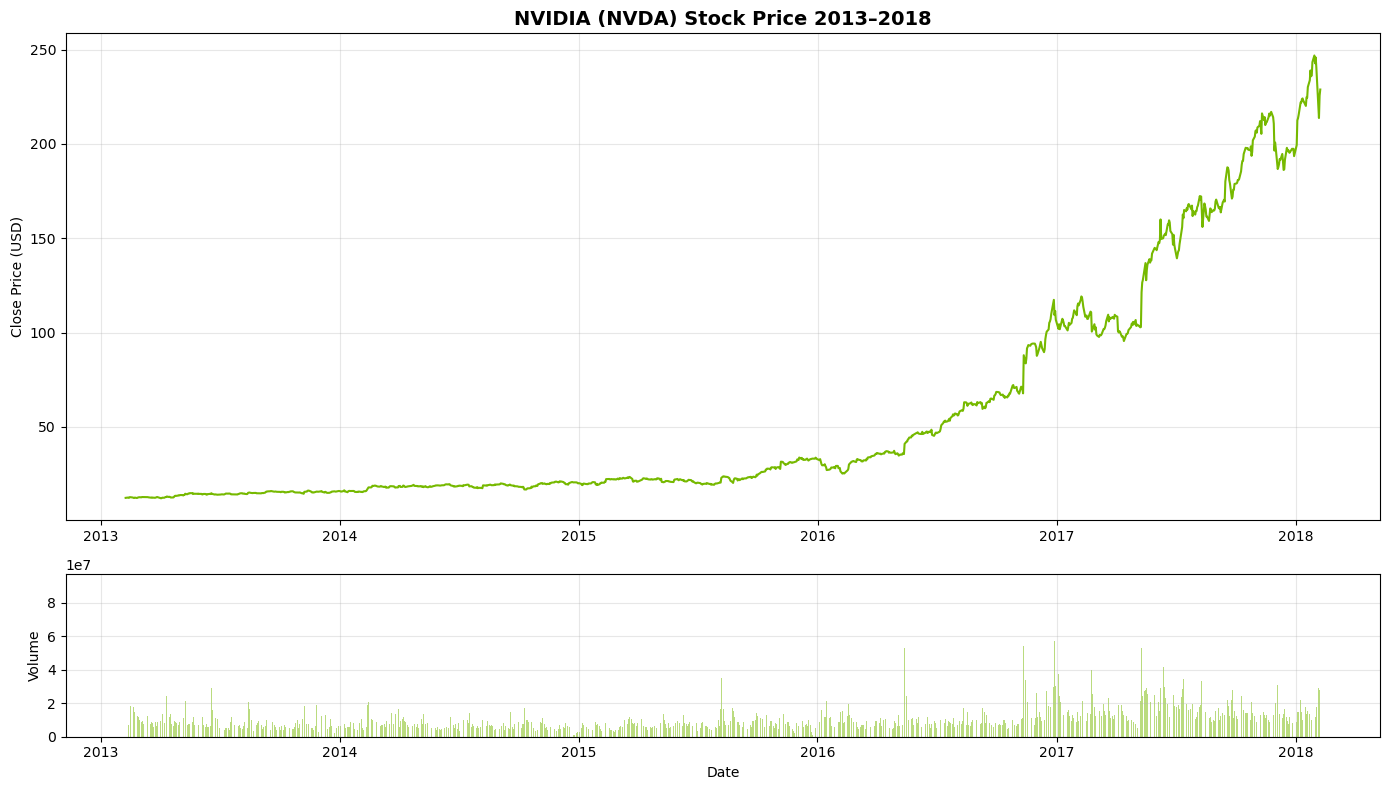

NVDA Price Summary:
Start price: $12.37
End price:   $228.80
Total return: 1749.6%


In [17]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

nvda = nvda.sort_values('date').reset_index(drop=True)

fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1])

# Price chart
ax1 = plt.subplot(gs[0])
ax1.plot(nvda['date'], nvda['close'], color='#76b900', linewidth=1.5)
ax1.set_title('NVIDIA (NVDA) Stock Price 2013–2018', fontsize=14, fontweight='bold')
ax1.set_ylabel('Close Price (USD)')
ax1.grid(True, alpha=0.3)

# Volume chart
ax2 = plt.subplot(gs[1])
ax2.bar(nvda['date'], nvda['volume'], color='#76b900', alpha=0.5)
ax2.set_ylabel('Volume')
ax2.set_xlabel('Date')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Key stats
print("NVDA Price Summary:")
print(f"Start price: ${nvda['close'].iloc[0]:.2f}")
print(f"End price:   ${nvda['close'].iloc[-1]:.2f}")
print(f"Total return: {((nvda['close'].iloc[-1] / nvda['close'].iloc[0]) - 1) * 100:.1f}%")


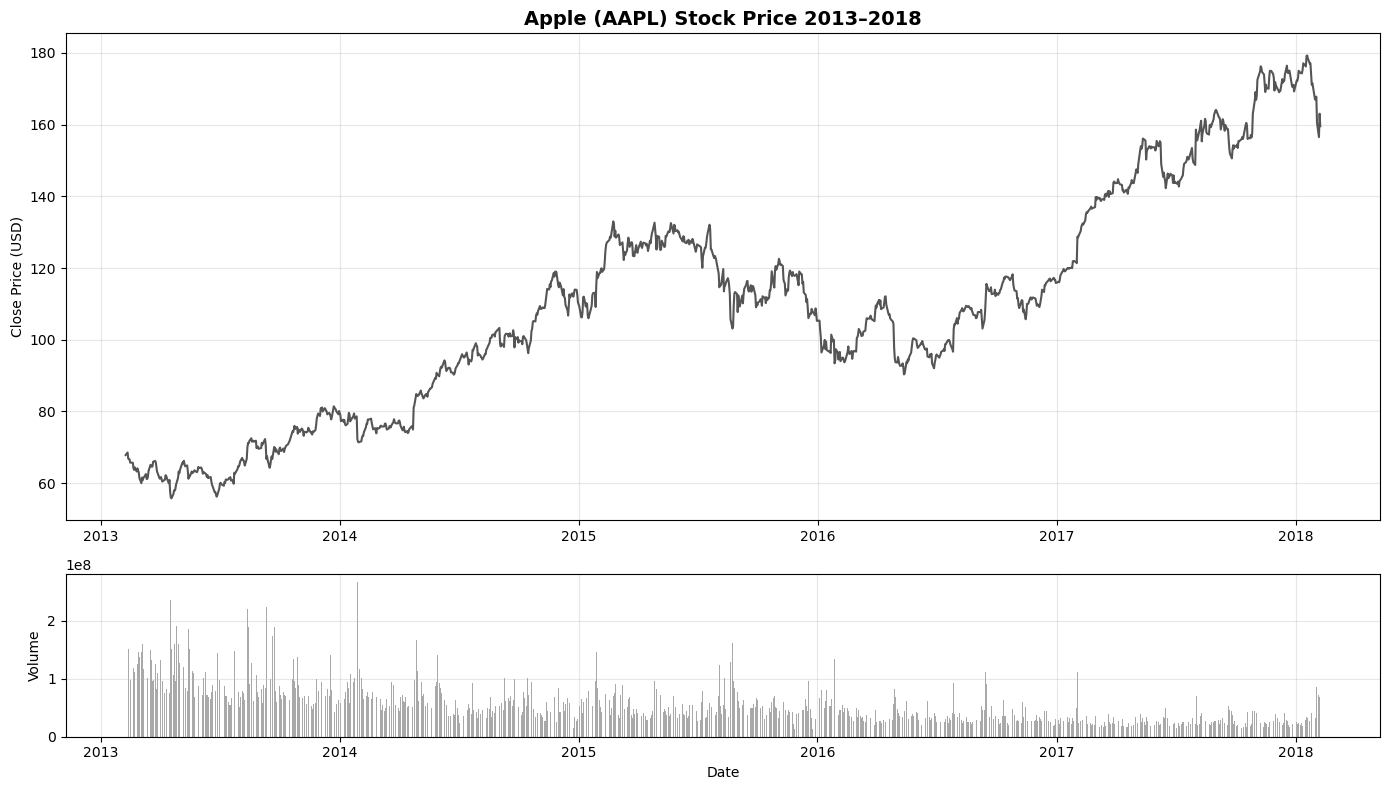

AAPL Price Summary:
Start price: $67.85
End price:   $159.54
Total return: 135.1%


In [18]:
aapl = df[df['Name'] == 'AAPL'].copy()
aapl = aapl.sort_values('date').reset_index(drop=True)

fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1])

ax1 = plt.subplot(gs[0])
ax1.plot(aapl['date'], aapl['close'], color='#555555', linewidth=1.5)
ax1.set_title('Apple (AAPL) Stock Price 2013–2018', fontsize=14, fontweight='bold')
ax1.set_ylabel('Close Price (USD)')
ax1.grid(True, alpha=0.3)

ax2 = plt.subplot(gs[1])
ax2.bar(aapl['date'], aapl['volume'], color='#555555', alpha=0.5)
ax2.set_ylabel('Volume')
ax2.set_xlabel('Date')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("AAPL Price Summary:")
print(f"Start price: ${aapl['close'].iloc[0]:.2f}")
print(f"End price:   ${aapl['close'].iloc[-1]:.2f}")
print(f"Total return: {((aapl['close'].iloc[-1] / aapl['close'].iloc[0]) - 1) * 100:.1f}%")


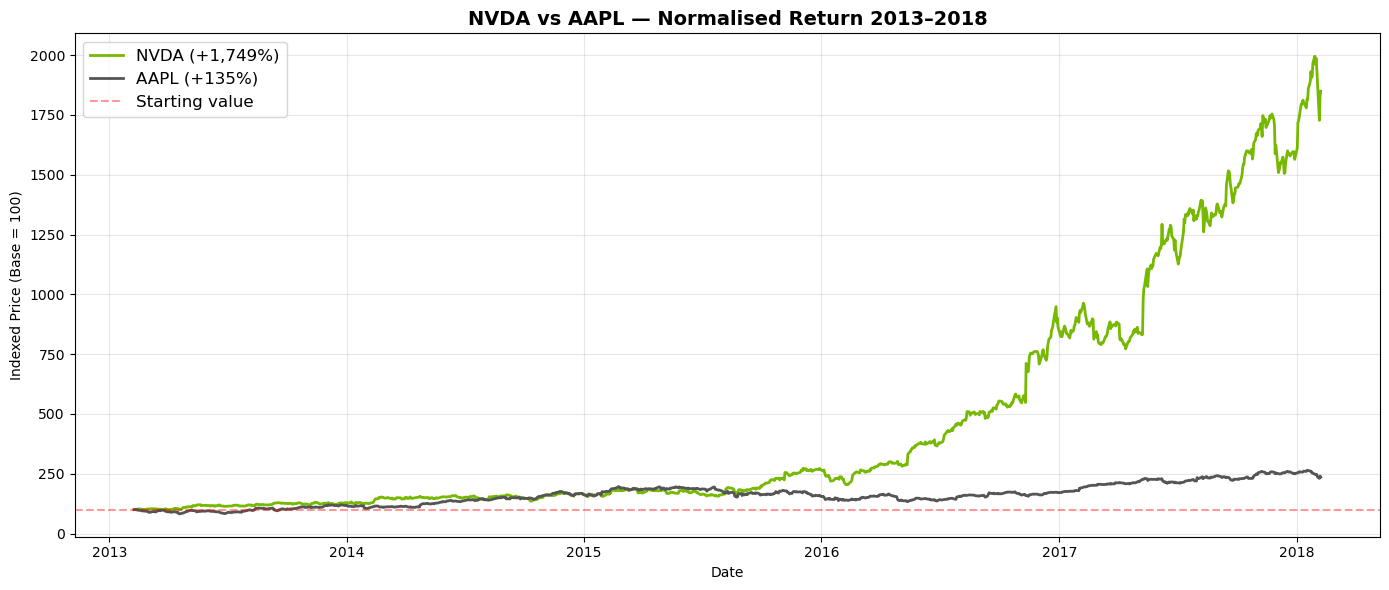

In [19]:
# Normalise both to 100 at start so they're comparable on the same axis
nvda_norm = nvda['close'] / nvda['close'].iloc[0] * 100
aapl_norm = aapl['close'] / aapl['close'].iloc[0] * 100

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(nvda['date'], nvda_norm, color='#76b900', linewidth=2, label='NVDA (+1,749%)')
ax.plot(aapl['date'], aapl_norm, color='#555555', linewidth=2, label='AAPL (+135%)')

ax.axhline(y=100, color='red', linestyle='--', alpha=0.4, label='Starting value')
ax.set_title('NVDA vs AAPL — Normalised Return 2013–2018', fontsize=14, fontweight='bold')
ax.set_ylabel('Indexed Price (Base = 100)')
ax.set_xlabel('Date')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [20]:
# Daily returns
nvda['daily_return'] = nvda['close'].pct_change()

# Moving averages
nvda['MA20'] = nvda['close'].rolling(window=20).mean()
nvda['MA50'] = nvda['close'].rolling(window=50).mean()

# Volatility (20-day rolling std of returns)
nvda['volatility'] = nvda['daily_return'].rolling(window=20).std()

# RSI (Relative Strength Index)
delta = nvda['close'].diff()
gain = delta.where(delta > 0, 0).rolling(window=14).mean()
loss = -delta.where(delta < 0, 0).rolling(window=14).mean()
rs = gain / loss
nvda['RSI'] = 100 - (100 / (1 + rs))

# Bollinger Bands
nvda['BB_upper'] = nvda['MA20'] + 2 * nvda['close'].rolling(20).std()
nvda['BB_lower'] = nvda['MA20'] - 2 * nvda['close'].rolling(20).std()

# Target variable — what we want to predict
# 1 = price goes UP next day, 0 = price goes DOWN
nvda['target'] = (nvda['close'].shift(-1) > nvda['close']).astype(int)

print("New features added:")
print(nvda[['date','close','MA20','MA50','RSI','volatility','BB_upper','BB_lower','target']].tail(10))
print("\nTarget distribution:")
print(nvda['target'].value_counts())


New features added:
           date   close      MA20      MA50        RSI  volatility  \
1249 2018-01-25  236.35  219.3845  208.1078  80.265957    0.019506   
1250 2018-01-26  243.33  221.6925  208.7218  82.651391    0.019845   
1251 2018-01-29  246.85  224.1650  209.3752  81.305115    0.019729   
1252 2018-01-30  242.72  226.6260  210.0300  73.743144    0.019488   
1253 2018-01-31  245.80  228.9485  210.7138  74.523282    0.018992   
1254 2018-02-01  240.50  230.3500  211.2966  66.420000    0.015345   
1255 2018-02-02  233.52  231.3465  211.6854  59.430923    0.017265   
1256 2018-02-05  213.70  231.2615  211.6384  45.599341    0.026379   
1257 2018-02-06  225.58  231.4405  211.8514  50.536829    0.028418   
1258 2018-02-07  228.80  231.7835  212.0882  52.625241    0.028565   

        BB_upper    BB_lower  target  
1249  246.626222  192.142778       1  
1250  248.831111  194.553889       1  
1251  250.993516  197.336484       0  
1252  250.475173  202.776827       1  
1253  250.5550

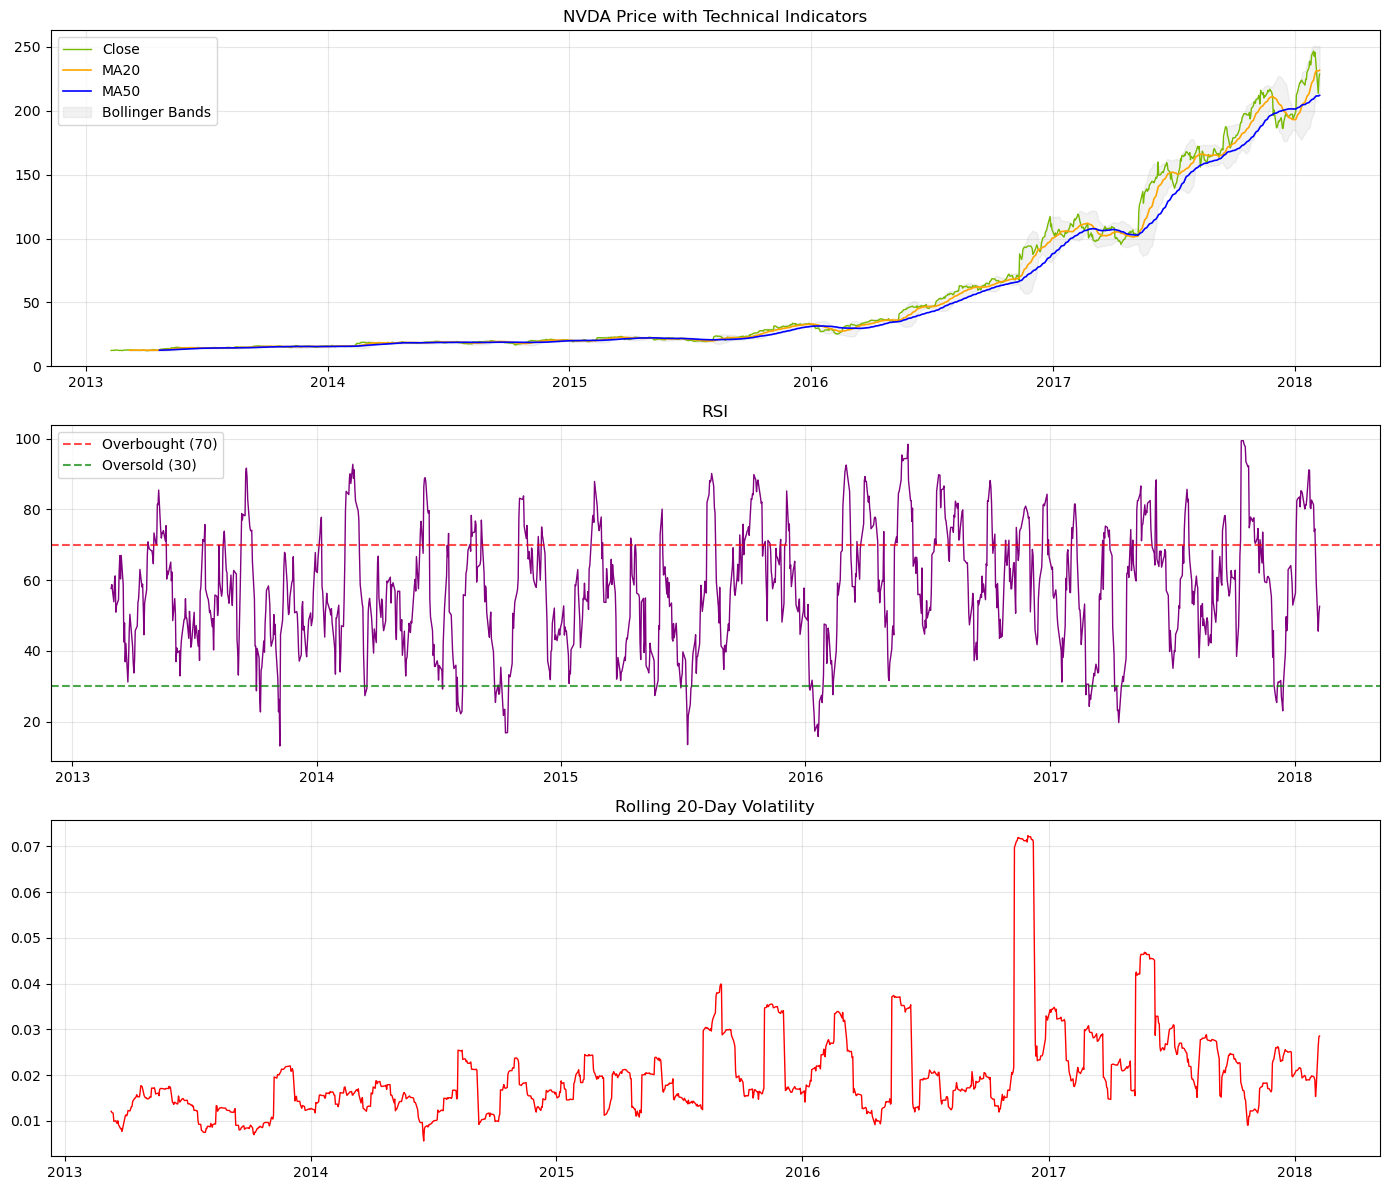

In [21]:
# Visualise the features we just built
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Price with Moving Averages and Bollinger Bands
axes[0].plot(nvda['date'], nvda['close'], label='Close', color='#76b900', linewidth=1)
axes[0].plot(nvda['date'], nvda['MA20'], label='MA20', color='orange', linewidth=1.2)
axes[0].plot(nvda['date'], nvda['MA50'], label='MA50', color='blue', linewidth=1.2)
axes[0].fill_between(nvda['date'], nvda['BB_upper'], nvda['BB_lower'], alpha=0.1, color='grey', label='Bollinger Bands')
axes[0].set_title('NVDA Price with Technical Indicators')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# RSI
axes[1].plot(nvda['date'], nvda['RSI'], color='purple', linewidth=1)
axes[1].axhline(70, color='red', linestyle='--', alpha=0.7, label='Overbought (70)')
axes[1].axhline(30, color='green', linestyle='--', alpha=0.7, label='Oversold (30)')
axes[1].set_title('RSI')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Volatility
axes[2].plot(nvda['date'], nvda['volatility'], color='red', linewidth=1)
axes[2].set_title('Rolling 20-Day Volatility')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.88      0.58       104
           1       0.59      0.14      0.22       138

    accuracy                           0.45       242
   macro avg       0.51      0.51      0.40       242
weighted avg       0.52      0.45      0.38       242

ROC-AUC Score: 0.5100


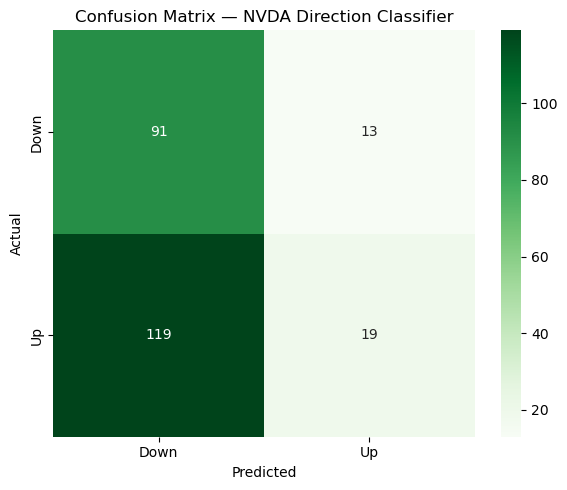

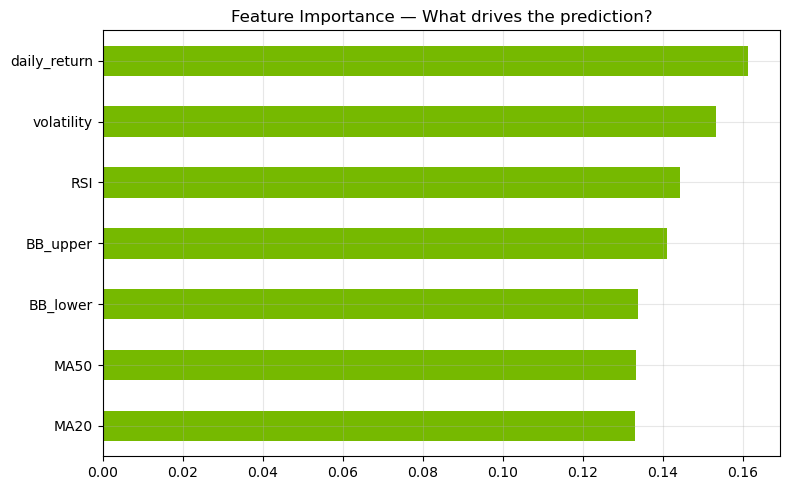

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns

# Prepare features
features = ['MA20', 'MA50', 'RSI', 'volatility', 'BB_upper', 'BB_lower', 'daily_return']
nvda_clean = nvda[features + ['target']].dropna()

X = nvda_clean[features]
y = nvda_clean['target']

# Split — important: no shuffling on time series data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Down', 'Up'],
            yticklabels=['Down', 'Up'])
ax.set_title('Confusion Matrix — NVDA Direction Classifier')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

# Feature Importance
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', color='#76b900', ax=ax)
ax.set_title('Feature Importance — What drives the prediction?')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
# Daily returns for risk analysis
nvda['daily_return'] = nvda['close'].pct_change()
aapl['daily_return'] = aapl['close'].pct_change()

# --- SHARPE RATIO ---
# Measures return per unit of risk. Higher = better.
# Risk-free rate ~2% annually = 0.02/252 daily
risk_free = 0.02 / 252

nvda_sharpe = (nvda['daily_return'].mean() - risk_free) / nvda['daily_return'].std() * (252 ** 0.5)
aapl_sharpe = (aapl['daily_return'].mean() - risk_free) / aapl['daily_return'].std() * (252 ** 0.5)

# --- VALUE AT RISK (95%) ---
# Worst expected loss on 95% of days
nvda_var = nvda['daily_return'].quantile(0.05)
aapl_var = aapl['daily_return'].quantile(0.05)

# --- MAX DRAWDOWN ---
# Biggest peak-to-trough drop ever experienced
def max_drawdown(returns):
    cumulative = (1 + returns).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    return drawdown.min()

nvda_mdd = max_drawdown(nvda['daily_return'].dropna())
aapl_mdd = max_drawdown(aapl['daily_return'].dropna())

print("=" * 45)
print(f"{'Metric':<25} {'NVDA':>8} {'AAPL':>8}")
print("=" * 45)
print(f"{'Total Return':<25} {'1749%':>8} {'135%':>8}")
print(f"{'Sharpe Ratio':<25} {nvda_sharpe:>8.2f} {aapl_sharpe:>8.2f}")
print(f"{'Daily VaR (95%)':<25} {nvda_var:>8.2%} {aapl_var:>8.2%}")
print(f"{'Max Drawdown':<25} {nvda_mdd:>8.2%} {aapl_mdd:>8.2%}")
print("=" * 45)

Metric                        NVDA     AAPL
Total Return                 1749%     135%
Sharpe Ratio                  1.76     0.77
Daily VaR (95%)             -2.72%   -2.28%
Max Drawdown               -25.27%  -32.08%


In [24]:
# Export cleaned NVDA and AAPL data with all features for Power BI
nvda['stock'] = 'NVDA'
aapl['stock'] = 'AAPL'

# Add risk metrics as columns for Power BI
nvda['daily_return'] = nvda['close'].pct_change()
aapl['daily_return'] = aapl['close'].pct_change()

# Normalised price (for comparison chart)
nvda['indexed_price'] = nvda['close'] / nvda['close'].iloc[0] * 100
aapl['indexed_price'] = aapl['close'] / aapl['close'].iloc[0] * 100

# Cumulative return
nvda['cumulative_return'] = (1 + nvda['daily_return']).cumprod() - 1
aapl['cumulative_return'] = (1 + aapl['daily_return']).cumprod() - 1

# Combine both into one dataframe
combined = pd.concat([nvda, aapl], ignore_index=True)

# Export
combined.to_csv('stock_analysis_powerbi.csv', index=False)
print("Exported successfully!")
print(f"Total rows: {len(combined)}")
print(f"Columns: {list(combined.columns)}")


Exported successfully!
Total rows: 2518
Columns: ['date', 'open', 'high', 'low', 'close', 'volume', 'Name', 'daily_return', 'MA20', 'MA50', 'volatility', 'RSI', 'BB_upper', 'BB_lower', 'target', 'stock', 'indexed_price', 'cumulative_return']
